# SpliceAI on CMC (COSMIC Cancer Mutation Census): splice-effect predictions

Same analysis as `spliceai_clinvar_exploration.ipynb`, applied to the CMC somatic mutation set. Loads the full SpliceAI results (`cmc_spliceai_scores.tsv`, built by `../12_variant_effect_prediction/splicing/`) -- 5,491,494 variants attempted, 5,070,804 scored (92.3%, nearly identical scoring rate to ClinVar's 92.5% -- the unscored fraction is a SpliceAI/annotation limitation, not a pipeline problem, and it's reassuringly consistent between the two independent variant sets).

**Data file is not checked into git** -- regenerate via `12_variant_effect_prediction/splicing/`, or pull `cmc_spliceai_scores.tsv` from `/u/project/kappel/ddcohn/protein_variant_effects/` on Hoffman2.

Unlike ClinVar, CMC's own source data is coding-mutation-only (see `12_variant_effect_prediction/README.md`), but SpliceAI itself still scores every variant's genomic context regardless -- so this table isn't restricted to exonic-only effects the way DeepLoc/protGPS's input is.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

SCORE_COLS = ["DS_AG", "DS_AL", "DS_DG", "DS_DL"]
LABELS = ["Acceptor Gain", "Acceptor Loss", "Donor Gain", "Donor Loss"]

## Load data

In [2]:
df = pd.read_csv("cmc_spliceai_scores.tsv", sep="\t")
print(f"{len(df):,} scored variants")
df.head()

5,070,804 scored variants


,GENOMIC_MUTATION_ID,DS_AG,DS_AL,DS_DG,DS_DL,DP_AG,DP_AL,DP_DG,DP_DL
0,COSV66112854,0.0,0.00,0.0,0.03,30,29,30,29
1,COSV66110116,0.0,0.06,0.0,0.00,2,-6,2,-6
2,COSV66113302,0.0,0.02,0.0,0.00,20,-8,-8,48
3,COSV66110478,0.0,0.00,0.0,0.00,6,-34,-2,-1
4,COSV66110166,0.0,0.00,0.0,0.00,48,32,-33,-14


## Delta score distributions

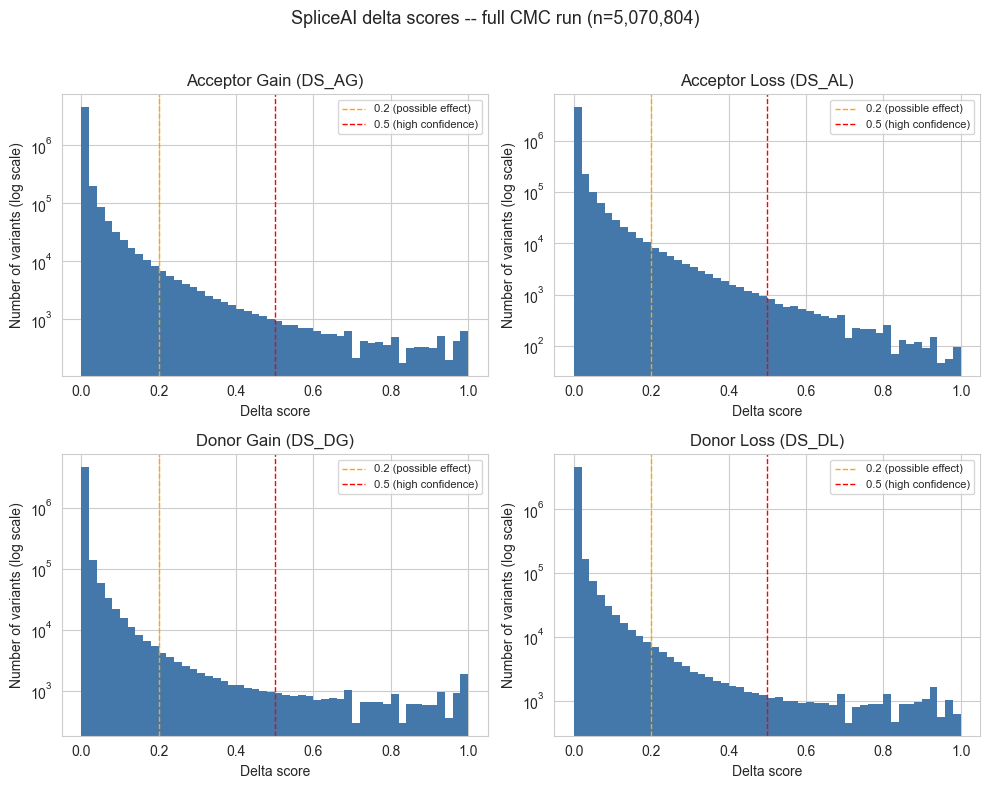

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, col, label in zip(axes.flat, SCORE_COLS, LABELS):
    ax.hist(df[col], bins=50, color="#4477AA", edgecolor="none")
    ax.set_yscale("log")
    ax.set_title(f"{label} ({col})")
    ax.set_xlabel("Delta score")
    ax.set_ylabel("Number of variants (log scale)")
    ax.axvline(0.2, color="orange", linestyle="--", linewidth=1, label="0.2 (possible effect)")
    ax.axvline(0.5, color="red", linestyle="--", linewidth=1, label="0.5 (high confidence)")
    ax.legend(fontsize=8)
fig.suptitle(f"SpliceAI delta scores -- full CMC run (n={len(df):,})", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## Summary counts

In [4]:
max_score = df[SCORE_COLS].max(axis=1)
print(f"Total scored variants: {len(df):,}")
print(f"Max delta score >= 0.2 (possible splicing effect): {(max_score >= 0.2).sum():,} "
      f"({(max_score >= 0.2).mean()*100:.2f}%)")
print(f"Max delta score >= 0.5 (high-confidence effect): {(max_score >= 0.5).sum():,} "
      f"({(max_score >= 0.5).mean()*100:.2f}%)")

Total scored variants: 5,070,804
Max delta score >= 0.2 (possible splicing effect): 201,048 (3.96%)
Max delta score >= 0.5 (high-confidence effect): 57,245 (1.13%)


## Variants with the strongest predicted splicing effect

In [5]:
top_variants = df.loc[max_score.sort_values(ascending=False).index[:25]]
top_variants[["GENOMIC_MUTATION_ID"] + SCORE_COLS + ["DP_AG", "DP_AL", "DP_DG", "DP_DL"]].head(25)

,GENOMIC_MUTATION_ID,DS_AG,DS_AL,DS_DG,DS_DL,DP_AG,DP_AL,DP_DG,DP_DL
4692383,COSV101208814,0.0,0.00,1.0,0.96,-20,3,-1,17
5040154,COSV64235127,0.0,0.00,1.0,0.71,26,50,1,-3
2488884,COSV107338411,0.0,0.00,1.0,0.25,-2,33,2,-2
3641809,COSV50623304,0.0,0.00,1.0,0.94,-36,-26,-2,-18
17007,COSV60034317,0.0,0.00,1.0,0.48,-13,-43,-1,3
656054,COSV100845958,0.0,0.00,1.0,0.78,40,-48,-1,40
2817401,COSV100859601,0.0,0.00,1.0,0.75,13,-11,1,-27
3331830,COSV107324960,0.0,0.00,1.0,0.82,-29,4,-2,6
2189231,COSV109652014,0.0,0.00,1.0,0.48,-2,46,2,-2
589063,COSV67981028,0.0,0.00,1.0,0.58,-30,-43,-1,3


## Which splicing mechanism dominates?

For variants with a high-confidence effect (max delta >= 0.5), which of the four delta scores is largest.

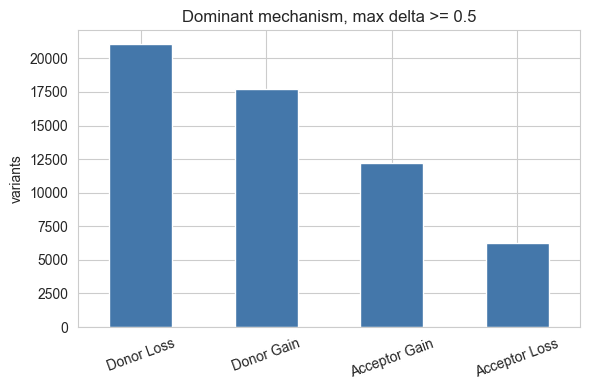

Donor Loss       21036
Donor Gain       17753
Acceptor Gain    12196
Acceptor Loss     6260
Name: count, dtype: int64

In [6]:
hi = df[max_score >= 0.5]
mech = hi[SCORE_COLS].idxmax(axis=1).map(dict(zip(SCORE_COLS, LABELS))).value_counts()
mech.plot.bar(color="#4477AA", figsize=(6, 4)); plt.ylabel("variants"); plt.title("Dominant mechanism, max delta >= 0.5")
plt.xticks(rotation=20); plt.tight_layout(); plt.show()
mech

## Where does the predicted splice change occur relative to the variant?

DP is the signed distance in bp from the variant to the affected splice site. High-confidence variants should cluster near the variant (SpliceAI looks +/- 50 bp).

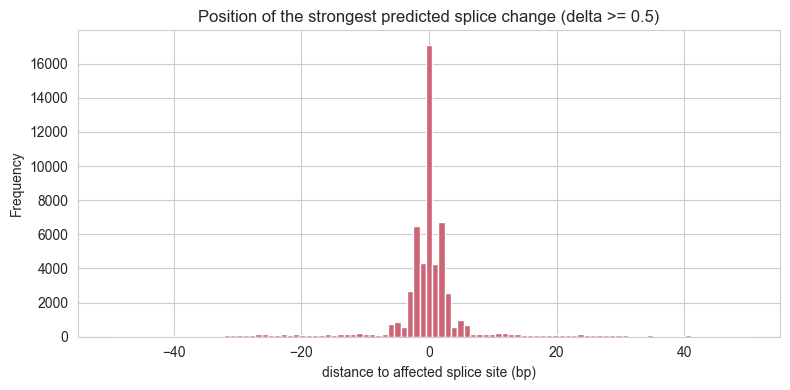

Within 2 bp of the variant: 67.9%


In [7]:
dp_cols = ["DP_AG", "DP_AL", "DP_DG", "DP_DL"]
best = hi[SCORE_COLS].values.argmax(axis=1)
dist = pd.Series([row[i] for row, i in zip(hi[dp_cols].values, best)])
dist.plot.hist(bins=101, range=(-50, 50), figsize=(8, 4), color="#CC6677")
plt.xlabel("distance to affected splice site (bp)"); plt.title("Position of the strongest predicted splice change (delta >= 0.5)"); plt.tight_layout(); plt.show()
print(f"Within 2 bp of the variant: {(dist.abs() <= 2).mean():.1%}")

## Which genes carry the most high-confidence splice-altering variants?

Somatic hotspots matter more than raw counts, so this joins gene names and variant class from the DeepLoc table (`cmc_deeploc_deltas.tsv`, protein-level variants only, so variants without a built protein sequence such as frameshifts are not annotated here).

In [8]:
ann = pd.read_csv("cmc_deeploc_deltas.tsv", sep="\t",
                  usecols=["GENOMIC_MUTATION_ID", "GENE_NAME", "category", "label_changed"] + [f"DELTA_{c}" for c in
                  ["Cytoplasm", "Nucleus", "Extracellular", "Cell membrane", "Mitochondrion", "Plastid",
                   "Endoplasmic reticulum", "Lysosome/Vacuole", "Golgi apparatus", "Peroxisome"]])
ann = ann.drop_duplicates("GENOMIC_MUTATION_ID")
df["max_splice"] = max_score
m = df.merge(ann, on="GENOMIC_MUTATION_ID", how="inner")
print(f"{len(m):,} of {len(df):,} scored variants have gene / protein-effect annotation")
m[m["max_splice"] >= 0.5]["GENE_NAME"].value_counts().head(20)

3,853,304 of 5,070,804 scored variants have gene / protein-effect annotation


GENE_NAME
TTN        165
ATM         99
LRP1B       96
NF1         74
CSMD3       65
KMT2D       63
OBSCN       60
CSMD1       53
USH2A       51
PKHD1L1     48
HMCN1       46
RYR2        45
DNAH7       42
DNAH5       41
SPTA1       41
KMT2C       41
ADGRV1      41
DNAH1       40
DNAH11      40
PREX2       40
Name: count, dtype: int64

## Splice effect by protein-level variant class

Fraction of each class with a possible (>= 0.2) or high-confidence (>= 0.5) splice effect. Missense and synonymous-like changes near exon boundaries can act through splicing rather than through the amino-acid change.

In [9]:
m.groupby("category")["max_splice"].agg(n="size", frac_ge_0_2=lambda x: (x >= 0.2).mean(), frac_ge_0_5=lambda x: (x >= 0.5).mean())

,n,frac_ge_0_2,frac_ge_0_5
category,,,
del,13,0.230769,0.076923
delins,1,0.000000,0.000000
dup,4,0.250000,0.000000
ins,21,0.000000,0.000000
missense,3600976,0.035875,0.010599
nonsense,252289,0.114892,0.028543


## Combining tools: splicing vs. localization

Variants where SpliceAI predicts a high-confidence splice effect and DeepLoc also predicts a localization shift are candidates where two mechanisms may act together. Note that DeepLoc scores the *unspliced* protein change, so a variant that truly disrupts splicing may not produce that protein at all -- the overlap is a flag for follow-up, not a confirmed double effect.

In [10]:
dl = [c for c in m.columns if c.startswith("DELTA_")]
m["max_loc_delta"] = m[dl].abs().max(axis=1)
both = m[(m["max_splice"] >= 0.5) & (m["max_loc_delta"] >= 0.5)]
print(f"High splice (>=0.5): {(m['max_splice'] >= 0.5).sum():,}")
print(f"High localization shift (>=0.5): {(m['max_loc_delta'] >= 0.5).sum():,}")
print(f"Both: {len(both):,}")
ct = pd.crosstab(m["max_splice"] >= 0.5, m["max_loc_delta"] >= 0.5, rownames=["splice>=0.5"], colnames=["loc>=0.5"])
print(ct)
both.sort_values("max_splice", ascending=False)[["GENOMIC_MUTATION_ID", "GENE_NAME", "category", "max_splice", "max_loc_delta"]].head(20)

High splice (>=0.5): 45,368
High localization shift (>=0.5): 51,788
Both: 1,021
loc>=0.5       False  True 
splice>=0.5                
False        3757169  50767
True           44347   1021


,GENOMIC_MUTATION_ID,GENE_NAME,category,max_splice,max_loc_delta
2088781,COSV55398439,SRBD1,missense,1.00,0.6195
2154937,COSV105873683,MICALL2,missense,1.00,0.6130
2565218,COSV104405857,IARS2,missense,1.00,0.8744
501512,COSV55419739,KIT,nonsense,1.00,0.8209
2071417,COSV62966715,C1orf43,missense,1.00,0.8459
1132993,COSV64373636,SELENBP1,nonsense,1.00,0.5236
1939898,COSV60710369,RET,nonsense,1.00,0.6347
2633534,COSV68597105,GOLGA2,missense,1.00,0.8326
2088946,COSV55405650,SRBD1,missense,1.00,0.7397
1006317,COSV51877559,MSH2,nonsense,1.00,0.6094
